In [1]:
from ModelClass import RegressionModel
from DatasetClass import Dataset, DatasetMass
from src.helpers import pick_only_target, extract_data, pick_only_mmc
import matplotlib.pyplot as plt
import numpy as np
import itertools
from src.helpers import make_filter_slice
import tensorflow as tf
#import optuna 
#from optuna_dashboard import run_server
import threading

2025-07-07 15:14:50.887203: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-07 15:14:50.898513: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751894090.910466 2294221 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751894090.914196 2294221 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-07 15:14:50.928328: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Available GPUs: []


2025-07-07 15:14:53.322530: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [ ]:
#Model_Name_phi = "PatrikNet_phi_flattened_17s_20_200.keras" 
#Model_Name = "PatrikNet_non_augmented.keras"
#Model_Name = "PatrikNet_mmc_flattened_lorentz_30cpus.keras"
Model_Name = "PatrikNet_mmc_flattened_lorentz_30cpus.keras"
#Model_Name= "PatrikNet_lorentz_flattened_17s_20_180_3epochs.keras" # for lorentz augmentation
#Model_Name = "PatrikNet_without_augmentation.keras" # for no augmentation

In [3]:
plt.rcParams.update({
    # from rootpy
    'lines.linewidth': 1,

    # font
    'font.family': 'sans-serif',
    'font.sans-serif': ['helvetica', 'Helvetica', 'Nimbus Sans L', 'Mukti Narrow', 'FreeSans'],
    'font.size': 18,
    'mathtext.fontset': 'stixsans',
    'mathtext.default': 'rm',

    # figure layout
    'figure.figsize': [8.75, 5.92],
    'figure.facecolor': 'white',
    'figure.subplot.bottom': 0.16,
    'figure.subplot.top': 0.93,
    'figure.subplot.left': 0.16,
    'figure.subplot.right': 0.95,

    # axes
    'axes.labelsize': 30,
    'axes.labelpad': 10,

    # ticks
    'xtick.top': True,
    'xtick.labelsize': 19,
    'xtick.major.size': 10,
    'xtick.minor.size': 5,
    'xtick.direction': 'in',
    'xtick.minor.visible': True,
    'ytick.right': True,
    'ytick.labelsize': 19,
    'ytick.major.size': 14,
    'ytick.minor.size': 7,
    'ytick.direction': 'in',
    'ytick.minor.visible': True,
    
    # lines
    'lines.markersize': 8,

    # legend
    'legend.numpoints': 1,
    'legend.fontsize': 18,
    'legend.labelspacing': 0.3,
    'legend.frameon': False,
})

In [2]:
dataset_h125 = DatasetMass()
dataset_h125.load_data(file_name = "data_h125")

dataset_Ztt = DatasetMass()
dataset_Ztt.load_data(file_name = "data_mmc")

In [5]:
#TRUE Golden Values
y_true_H125 = np.array(extract_data(dataset_h125.val_dataset.map(pick_only_target)))
y_true_Ztt = np.array(extract_data(dataset_Ztt.val_dataset.map(pick_only_target)))

y_true_H125 = np.concatenate([y_true_H125, np.array(extract_data(dataset_h125.dev_dataset.map(pick_only_target)))])
y_true_Ztt = np.concatenate([y_true_Ztt, np.array(extract_data(dataset_Ztt.dev_dataset.map(pick_only_target)))])

2025-07-07 15:17:14.753979: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-07-07 15:17:50.218743: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-07-07 15:18:55.010326: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [6]:
#MMC Predictions
y_mmc_Ztt = np.array(extract_data(dataset_Ztt.val_dataset.map(pick_only_mmc)))
y_mmc_H125 = np.array(extract_data(dataset_h125.val_dataset.map(pick_only_mmc)))

y_mmc_Ztt = np.concatenate([y_mmc_Ztt, np.array(extract_data(dataset_Ztt.dev_dataset.map(pick_only_mmc)))])
y_mmc_H125 = np.concatenate([y_mmc_H125, np.array(extract_data(dataset_h125.dev_dataset.map(pick_only_mmc)))])


2025-07-07 15:21:07.546161: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
# NN Predictions
print("Predicting Ztt masses...")
model_Ztt = RegressionModel(dataset=dataset_Ztt)
model_Ztt.load(model_name=Model_Name)
y_pred_Ztt = model_Ztt.model.predict(dataset_Ztt.val_dataset.batch(10000)).squeeze()
y_pred_Ztt = np.concatenate([y_pred_Ztt, model_Ztt.model.predict(dataset_Ztt.dev_dataset.batch(10000)).squeeze()])

print("Predicting H125 masses...")
model_H125 = RegressionModel(dataset=dataset_h125)
model_H125.load(model_name=Model_Name)
y_pred_H125 = model_H125.model.predict(dataset_h125.val_dataset.batch(10000)).squeeze()
y_pred_H125 = np.concatenate([y_pred_H125, model_H125.model.predict(dataset_h125.dev_dataset.batch(10000)).squeeze()])

Predicting Ztt masses...
Number of devices: 1
Model loaded from /home/ivanpa/HiggsAnalysisBc/models/PatrikNet_mmc_flattened_lorentz_30cpus.keras


I0000 00:00:1751894468.306709 2296842 service.cc:148] XLA service 0x7fed8c005db0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1751894468.306764 2296842 service.cc:156]   StreamExecutor device (0): Host, Default Version
2025-07-07 15:21:08.317429: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1751894468.477262 2296842 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step
Predicting H125 masses...
Number of devices: 1
Model loaded from /home/ivanpa/HiggsAnalysisBc/models/PatrikNet_mmc_flattened_lorentz_30cpus.keras
82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 155ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step


NameError: name 'y_mmc_Ztt' is not defined

findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not foun

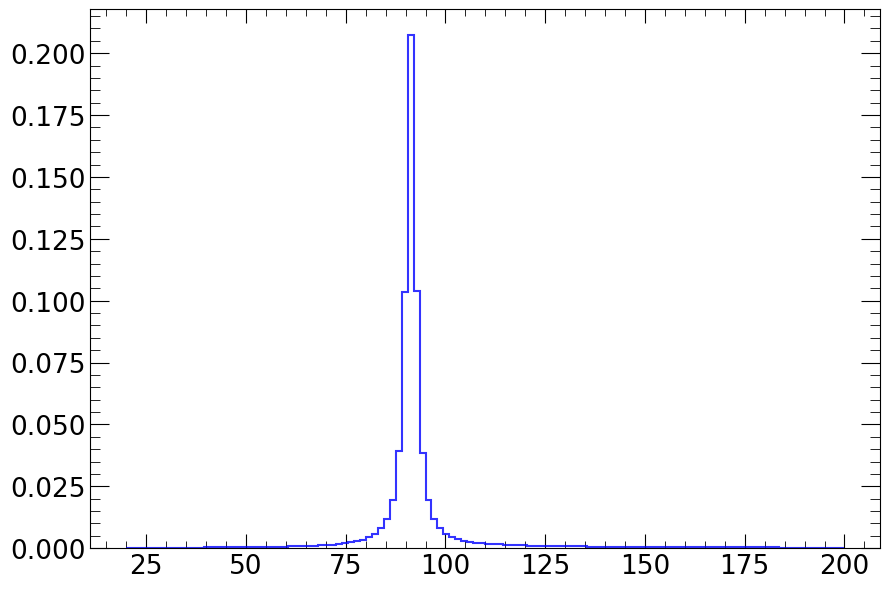

In [ ]:
# MMC vs NN vs True Ztt
plt.figure(figsize=(10, 7))

plt.hist(y_true_Ztt, bins=120, range=(20, 200), histtype='step',
         label='True Ztt', density=True, color='blue', alpha=0.8, linewidth=1.5)
plt.hist(y_mmc_Ztt, bins=120, range=(20, 200), histtype='step',
         label='MMC Ztt', density=True, color='red', alpha=0.8, linewidth=1.5)
plt.hist(y_pred_Ztt, bins=120, range=(20, 200), histtype='step',
         label='NN Ztt', density=True, color='Orange', alpha=0.8, linewidth=1.5)

plt.xlabel(r'Mass [GeV]', fontsize=16, horizontalalignment='right', x=1)
plt.ylabel(r'Density', fontsize=16, horizontalalignment='right', y=1)
plt.xlim(50, 130)
plt.legend(fontsize=12, loc='upper right')
plt.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6, width=1)
plt.savefig('out_lorentz/Ztt_True_NN_MMC.png', dpi=300)
plt.tight_layout()
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not foun

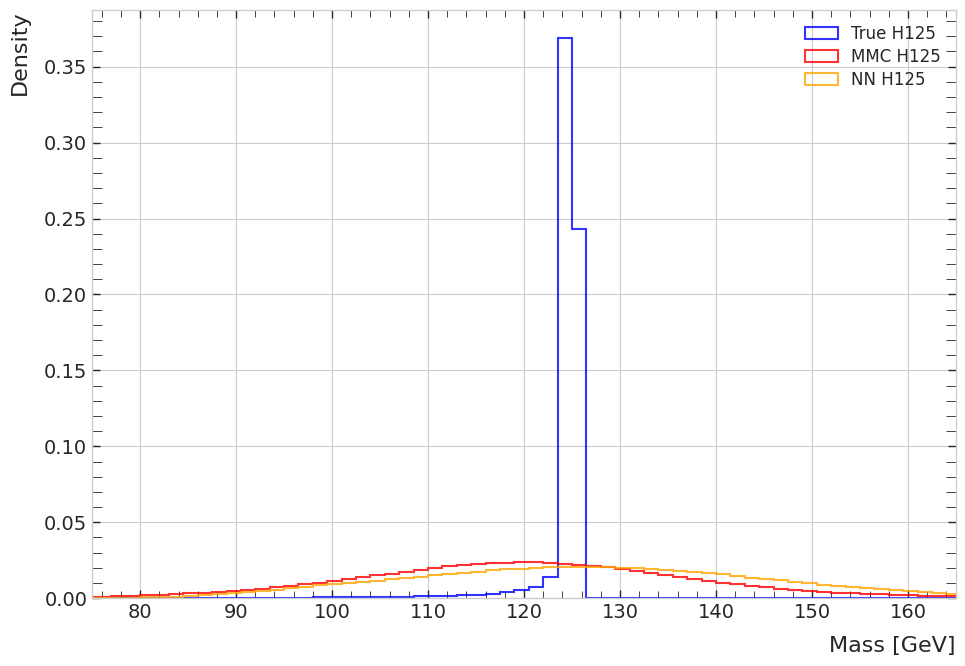

In [50]:
# MMC vs NN vs True H125
plt.figure(figsize=(10, 7))
plt.hist(y_true_H125, bins=120, range=(20, 200), histtype='step',
         label='True H125', density=True, color='blue', alpha=0.8, linewidth=1.5)
plt.hist(y_mmc_H125, bins=120, range=(20, 200), histtype='step',
         label='MMC H125', density=True, color='red', alpha=0.8, linewidth=1.5)
plt.hist(y_pred_H125, bins=120, range=(20, 200), histtype='step',
         label='NN H125', density=True, color='Orange', alpha=0.8, linewidth=1.5)       
plt.xlabel(r'Mass [GeV]', fontsize=16, horizontalalignment='right', x=1)
plt.ylabel(r'Density', fontsize=16, horizontalalignment='right', y=1)
plt.xlim(75, 165)
plt.legend(fontsize=12, loc='upper right')
plt.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6, width=1)
#plt.savefig('out/H125_True_NN_MMC.png', dpi=300)
plt.tight_layout()
plt.show()      

findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not foun

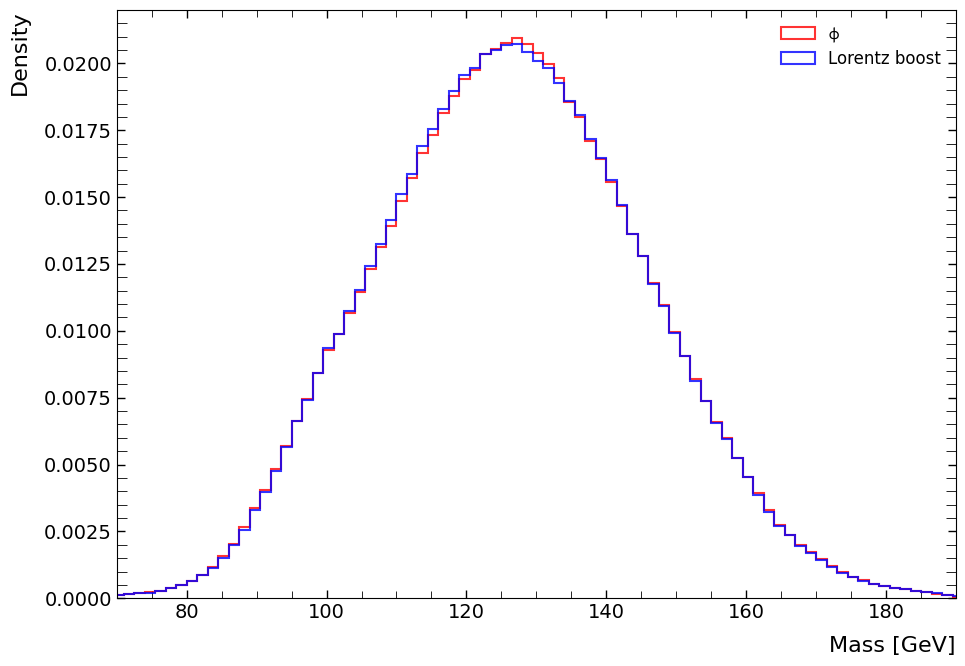

In [ ]:
# MMC vs NN vs True H125
plt.figure(figsize=(10, 7))

plt.hist(y_pred_Ztt, bins=120, range=(20, 200), histtype='step',
         label='NN Ztt', density=True, color='red', alpha=0.8, linewidth=1.5)
plt.hist(y_true_Ztt, bins=120, range=(20, 200), histtype='step',
         label='True Ztt', density=True, color='blue', alpha=0.8, linewidth=1.5)       
plt.hist(y_mmc_Ztt, bins=120, range=(20, 200), histtype='step',
         label='MMC Ztt', density=True, color='green', alpha=0.8, linewidth=1.5)
plt.xlabel(r'Mass [GeV]', fontsize=16, horizontalalignment='right', x=1)
plt.ylabel(r'Density', fontsize=16, horizontalalignment='right', y=1)
plt.xlim(70, 190)
plt.legend(fontsize=12, loc='upper right')
plt.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6, width=1)
plt.savefig('out_non_augmented/Ztt_NN_MMC_True.png', dpi=300)
plt.tight_layout()
plt.show()      

findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not foun

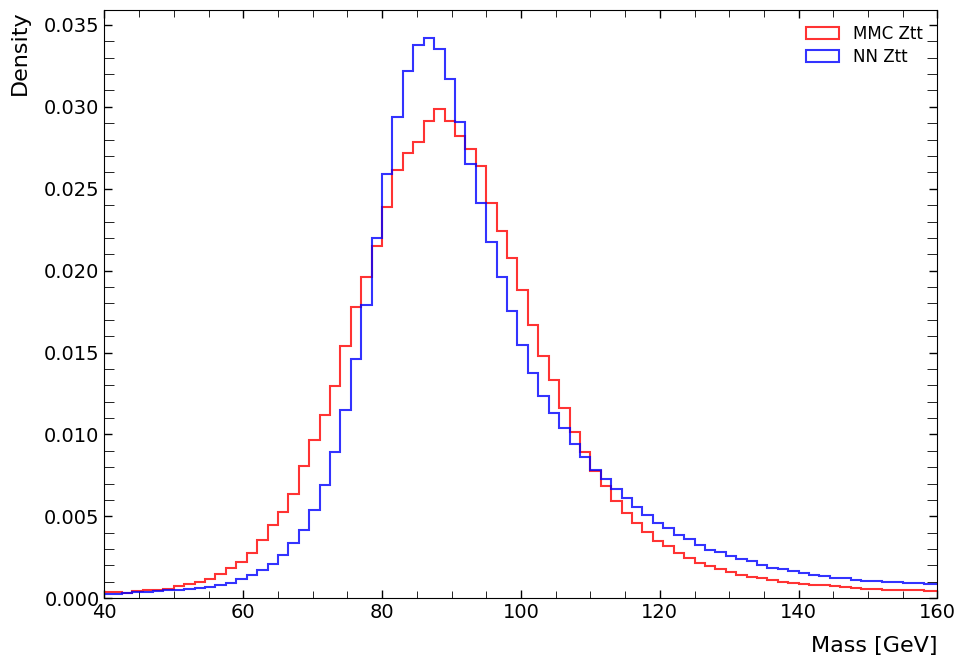

In [ ]:
# MMC vs NN Ztt
plt.figure(figsize=(10, 7))
plt.hist(y_mmc_Ztt, bins=120, range=(20, 200), histtype='step',
         label='MMC Ztt', density=True, color='red', alpha=0.8, linewidth=1.5)
plt.hist(y_pred_Ztt, bins=120, range=(20, 200), histtype='step',
         label='NN Ztt', density=True, color='Blue', alpha=0.8, linewidth=1.5)
plt.xlabel(r'Mass [GeV]', fontsize=16, horizontalalignment='right', x=1)
plt.ylabel(r'Density', fontsize=16, horizontalalignment='right', y=1)
plt.xlim(40, 160)
plt.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6, width=1)
plt.legend(fontsize=12, loc='upper right')          
plt.savefig('out_non_augmented/Ztt_NN_MMC_non_augmented.png', dpi=300)
plt.tight_layout()
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not foun

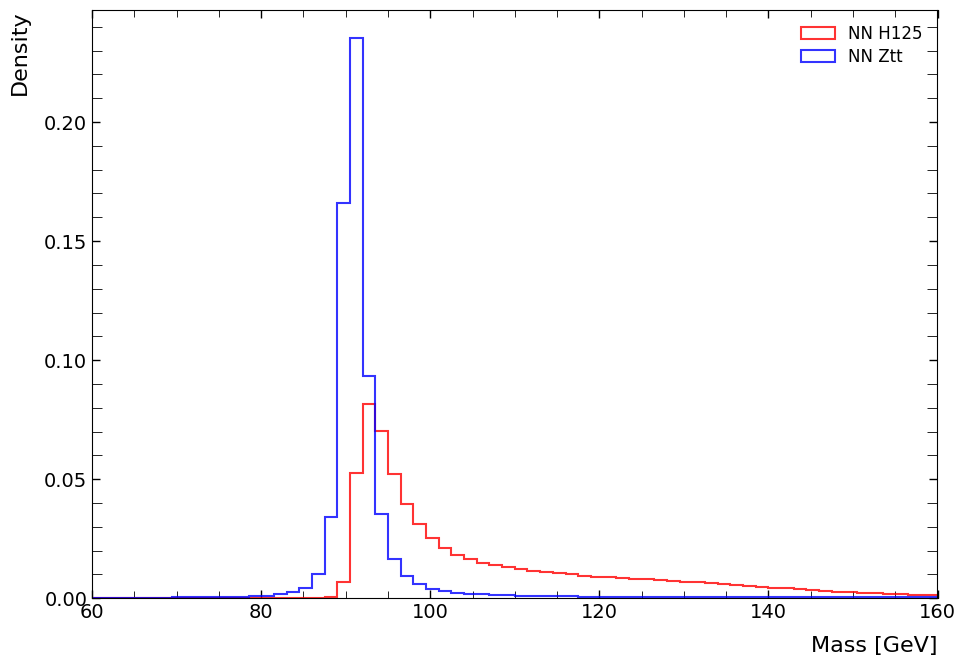

In [19]:
# MMC vs NN Ztt
plt.figure(figsize=(10, 7))
plt.hist(y_pred_H125, bins=120, range=(20, 200), histtype='step',
         label='NN H125', density=True, color='red', alpha=0.8, linewidth=1.5)
plt.hist(y_pred_Ztt, bins=120, range=(20, 200), histtype='step',
         label='NN Ztt', density=True, color='Blue', alpha=0.8, linewidth=1.5)
plt.xlabel(r'Mass [GeV]', fontsize=16, horizontalalignment='right', x=1)
plt.ylabel(r'Density', fontsize=16, horizontalalignment='right', y=1)
plt.xlim(60, 160)
plt.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6, width=1)
plt.legend(fontsize=12, loc='upper right')          
plt.savefig('out_non_augmented/H125_Ztt_NN.png', dpi=300)
plt.tight_layout()
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not foun

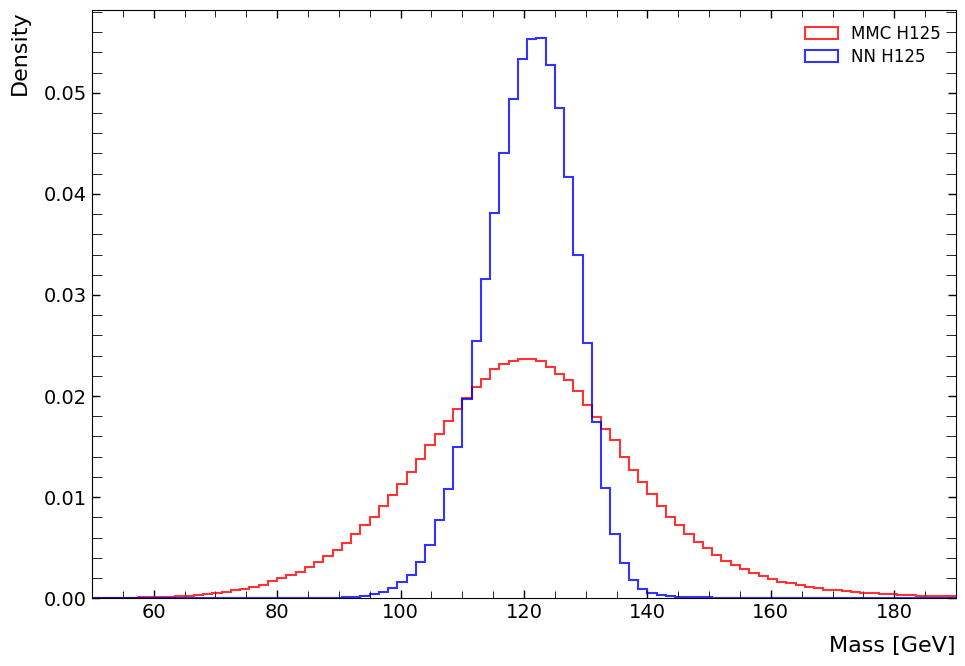

In [11]:
# MMC vs NN Ztt


plt.figure(figsize=(10, 7))
plt.hist(y_mmc_H125, bins=120, range=(20, 200), histtype='step',
         label='MMC H125', density=True, color='red', alpha=0.8, linewidth=1.5)
plt.hist(y_pred_H125, bins=120, range=(20, 200), histtype='step',
         label='NN H125', density=True, color='blue', alpha=0.8, linewidth=1.5)
plt.xlabel(r'Mass [GeV]', fontsize=16, horizontalalignment='right', x=1)
plt.ylabel(r'Density', fontsize=16, horizontalalignment='right', y=1)
plt.xlim(50, 190)
plt.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6, width=1)
plt.legend(fontsize=12, loc='upper right')          
plt.savefig('out_discussion/H125_NN_MMC.png', dpi=300)
plt.tight_layout()
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not foun

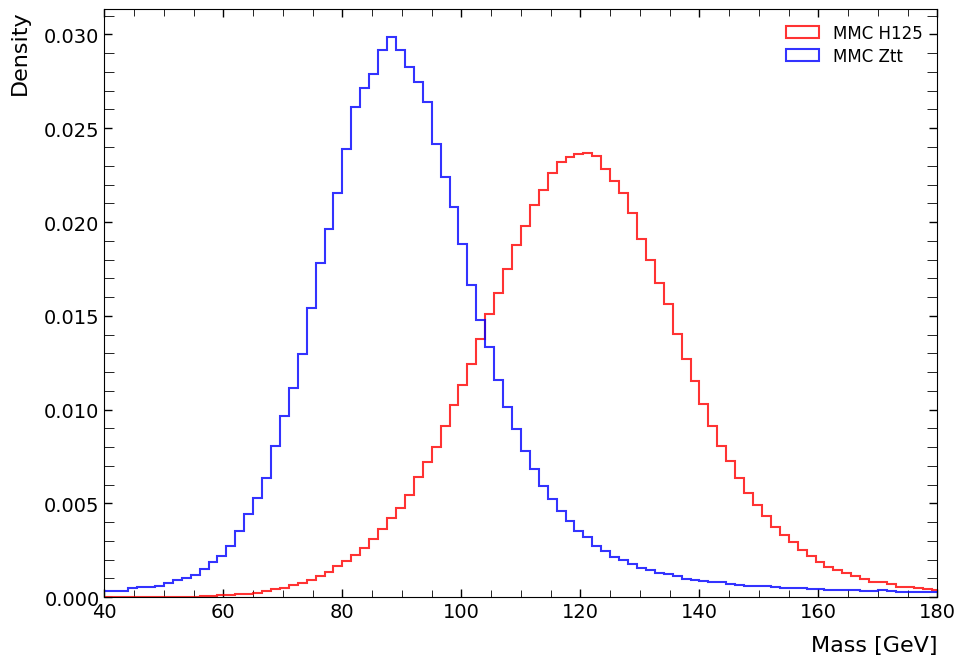

In [ ]:
#MMC vs MMC H125 Ztt
plt.figure(figsize=(10, 7))
plt.hist(y_mmc_H125, bins=120, range=(20, 200), histtype='step',label='MMC H125', density=True, color='red', alpha=0.8, linewidth=1.5)
plt.hist(y_mmc_Ztt, bins=120, range=(20, 200), histtype='step',label='MMC Ztt', density=True, color='Blue', alpha=0.8, linewidth=1.5)
plt.xlabel(r'Mass [GeV]', fontsize=16, horizontalalignment='right', x=1)
plt.ylabel(r'Density', fontsize=16, horizontalalignment='right', y=1)
plt.xlim(40, 180)
plt.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6, width=1)
plt.legend(fontsize=12, loc='upper right')          
#plt.savefig('out_lorentz/H125_Ztt_MMC_lorentz.png', dpi=300)
plt.tight_layout()
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not foun

--- Výsledky Gaussovho fitu pre NN H125 ---
Stred (μ): 126.0917 GeV
Smerodajná odchýlka (σ): 19.4406 GeV
Amplitúda (A): 0.0207
--- Výsledky Gaussovho fitu pre MMC H125 ---
Stred (μ): 119.9669 GeV
Smerodajná odchýlka (σ): 16.7773 GeV
Amplitúda (A): 0.0233


findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not foun

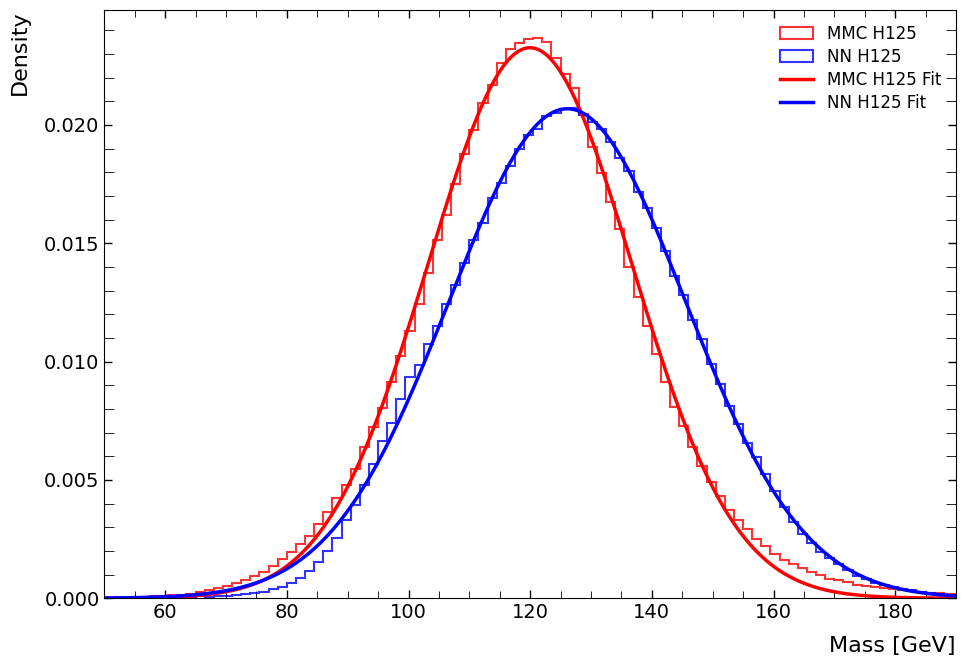

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

def gaussian(x, A, mu, sigma):
    return 1/(2*np.pi*sigma**2) * np.exp(-(x - mu)**2 / (2 * sigma**2))

bins = 120
fit_range = (20, 200)

hist_data, bin_edges = np.histogram(y_pred_H125, bins=bins, range=fit_range, density=True)
hist_data_mmc, bin_edges_mmc = np.histogram(y_mmc_H125, bins=bins, range=fit_range, density=True)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_centers_mmc = (bin_edges_mmc[:-1] + bin_edges_mmc[1:]) / 2

mu_guess = np.mean(y_pred_H125)
sigma_guess = np.std(y_pred_H125)
A_guess = np.max(hist_data) 

mu_guess_mmc = np.mean(y_mmc_H125)
sigma_guess_mmc = np.std(y_mmc_H125)
A_guess_mmc = np.max(hist_data_mmc) 

params_mmc, covariance_mmc = curve_fit(gaussian, bin_centers_mmc, hist_data_mmc, p0=[A_guess_mmc, mu_guess_mmc, sigma_guess_mmc])
params, covariance = curve_fit(gaussian, bin_centers, hist_data, p0=[A_guess, mu_guess, sigma_guess])

A_fit, mu_fit, sigma_fit = params
A_fit_true, mu_fit_true, sigma_fit_true = params_mmc

print("--- Výsledky Gaussovho fitu pre NN H125 ---")
print(f"Stred (μ): {mu_fit:.4f} GeV")
print(f"Smerodajná odchýlka (σ): {sigma_fit:.4f} GeV")
print(f"Amplitúda (A): {A_fit:.4f}")

print("--- Výsledky Gaussovho fitu pre MMC H125 ---")
print(f"Stred (μ): {mu_fit_true:.4f} GeV")
print(f"Smerodajná odchýlka (σ): {sigma_fit_true:.4f} GeV")
print(f"Amplitúda (A): {A_fit_true:.4f}")

plt.figure(figsize=(10, 7))
plt.hist(y_mmc_H125, bins=bins, range=fit_range, histtype='step',
         label='MMC H125', density=True, color='red', alpha=0.8, linewidth=1.5)
plt.hist(y_pred_H125, bins=bins, range=fit_range, histtype='step',
         label='NN H125', density=True, color='Blue', alpha=0.8, linewidth=1.5)

x_fit = np.linspace(fit_range[0], fit_range[1], 500)
plt.plot(x_fit, gaussian(x_fit, *params_mmc), color='red', linewidth=2.5,
         label=f'MMC H125 Fit')
plt.plot(x_fit, gaussian(x_fit, *params), color='blue', linewidth=2.5,
         label=f'NN H125 Fit')

plt.xlabel(r'Mass [GeV]', fontsize=16, horizontalalignment='right', x=1)
plt.ylabel(r'Density', fontsize=16, horizontalalignment='right', y=1)
plt.xlim(50, 190)
plt.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6, width=1)
plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()
plt.savefig('out_lorentz/H125_NN_MMC_lorentz_with_fit.png', dpi=300)
plt.show()


findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not foun

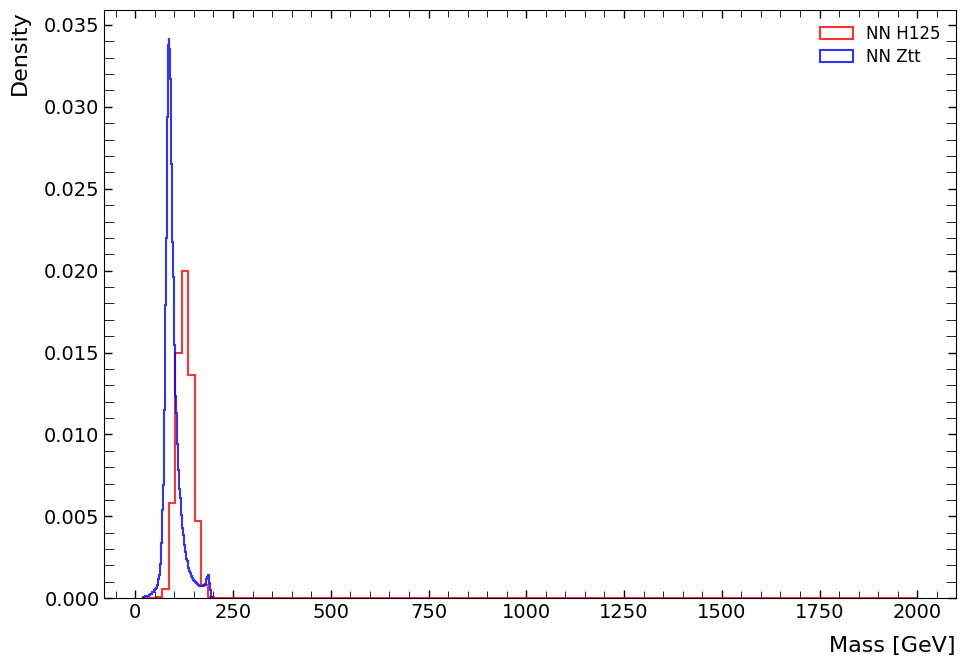

In [ ]:
#NN vs NN H125 Ztt
plt.figure(figsize=(10, 7))
plt.hist(y_pred_H125, bins=120, range=(20, 2000), histtype='step',
         label='NN H125', density=True, color='red', alpha=0.8, linewidth=1.5)
plt.hist(y_pred_Ztt, bins=120, range=(20, 200), histtype='step',
         label='NN Ztt', density=True, color='Blue', alpha=0.8, linewidth=1.5)
plt.xlabel(r'Mass [GeV]', fontsize=16, horizontalalignment='right', x=1)
plt.ylabel(r'Density', fontsize=16, horizontalalignment='right', y=1)
#plt.xlim(40, 180)
plt.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6, width=1)
plt.legend(fontsize=12, loc='upper right')          
#plt.savefig('out_lorentz/H125_Ztt_NN_lorentz.png', dpi=300)
plt.tight_layout()
plt.show()  

findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not foun

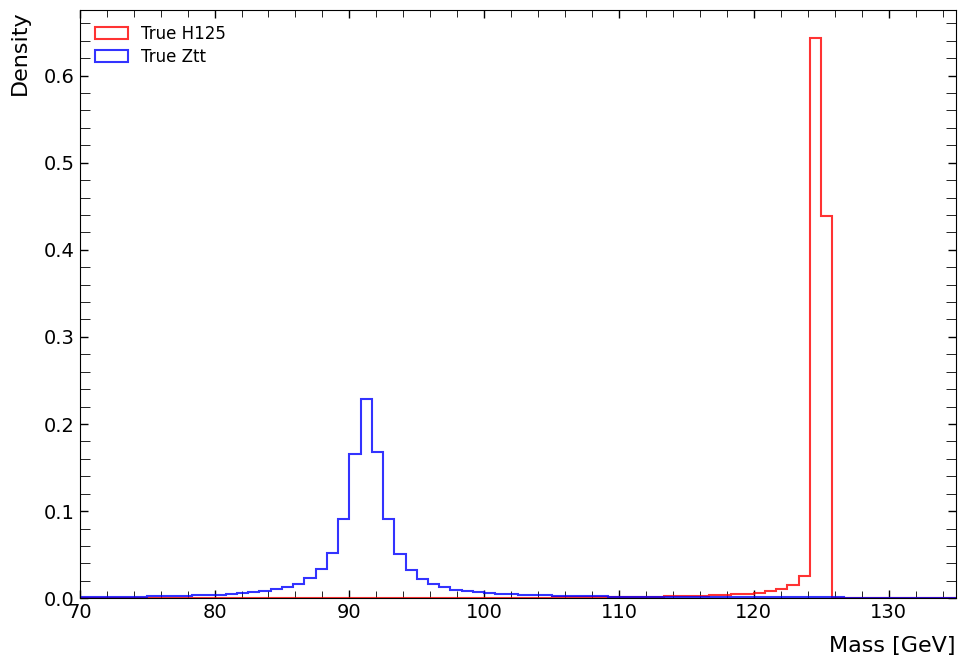

In [ ]:
# H125 vs Ztt True
plt.figure(figsize=(10, 7))
plt.hist(y_true_H125, bins=120, range=(70, 170), histtype='step',
         label='True H125', density=True, color='red', alpha=0.8, linewidth=1.5)
plt.hist(y_true_Ztt, bins=120, range=(70, 170), histtype='step',
         label='True Ztt', density=True, color='Blue', alpha=0.8, linewidth=1.5)
plt.xlabel(r'Mass [GeV]', fontsize=16, horizontalalignment='right', x=1)
plt.ylabel(r'Density', fontsize=16, horizontalalignment='right', y=1)
plt.xlim(70, 135)
plt.legend(fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6, width=1)
plt.savefig('out_lorentz/H125_Ztt_True_lorentz.png', dpi=300)
plt.tight_layout()
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not foun

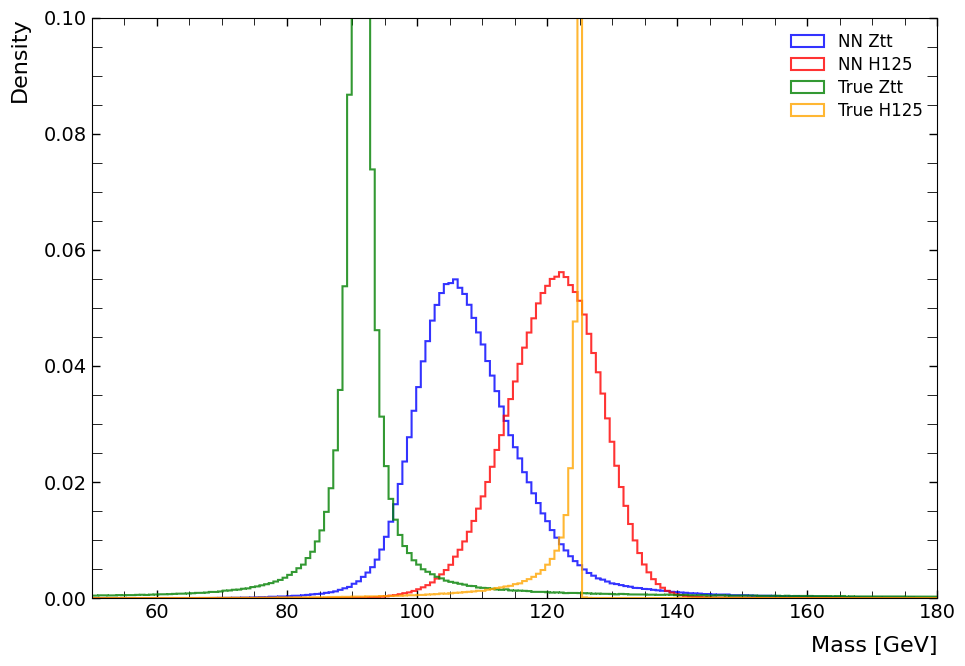

In [17]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

combined_data = np.concatenate([y_mmc_Ztt, y_mmc_H125, y_pred_Ztt, y_pred_H125])
optimal_bins = np.histogram_bin_edges(combined_data, bins="sqrt")


plt.figure(figsize=(10, 7))
#plt.hist(y_mmc_Ztt, bins=optimal_bins, histtype='step', label=f'MMC Ztt', density=True, color='blue', alpha=0.8, linewidth=1.5)
#plt.hist(y_mmc_H125, bins=optimal_bins, histtype='step', label=f'MMC H125', density=True, color='red', alpha=0.8, linewidth=1.5)
plt.hist(y_pred_Ztt, bins=optimal_bins, histtype='step', label=f'NN Ztt', density=True, color='blue', alpha=0.8, linewidth=1.5)
plt.hist(y_pred_H125, bins=optimal_bins, histtype='step', label=f'NN H125', density=True, color='red', alpha=0.8, linewidth=1.5)
plt.hist(y_true_Ztt, bins=optimal_bins, histtype='step', label=f'True Ztt', density=True, color='green', alpha=0.8, linewidth=1.5)
plt.hist(y_true_H125, bins=optimal_bins, histtype='step', label=f'True H125', density=True, color='orange', alpha=0.8, linewidth=1.5)
plt.xlabel(r'Mass [GeV]', fontsize=16, horizontalalignment='right', x=1)
plt.ylabel(r'Density', fontsize=16, horizontalalignment='right', y=1)
plt.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6, width=1)
plt.xlim(50, 180)
plt.ylim(0, 0.1)
plt.tight_layout()
plt.grid(False)

plt.legend(fontsize=12)
plt.savefig("out_discussion/nn_separation.png", dpi=300)

# --- Rest of your original code if needed for prediction comparison ---
# y_pred = model.model.predict(dataset_h125_obj.val_dataset.batch(10000)).squeeze()
# y_pred_Ztt = model.model.predict(dataset_Ztt_obj.val_dataset.batch(10000)).squeeze()

findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not foun

Distribution    | Peak (GeV)      | FWHM (GeV)     
--------------------------------------------------
MMC Ztt         | 0.35            | 97.73          
MMC H125        | 120.75          | 138.10         
NN Ztt          | 105.88          | 15.58          
NN H125         | 122.17          | 16.29          


findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not foun

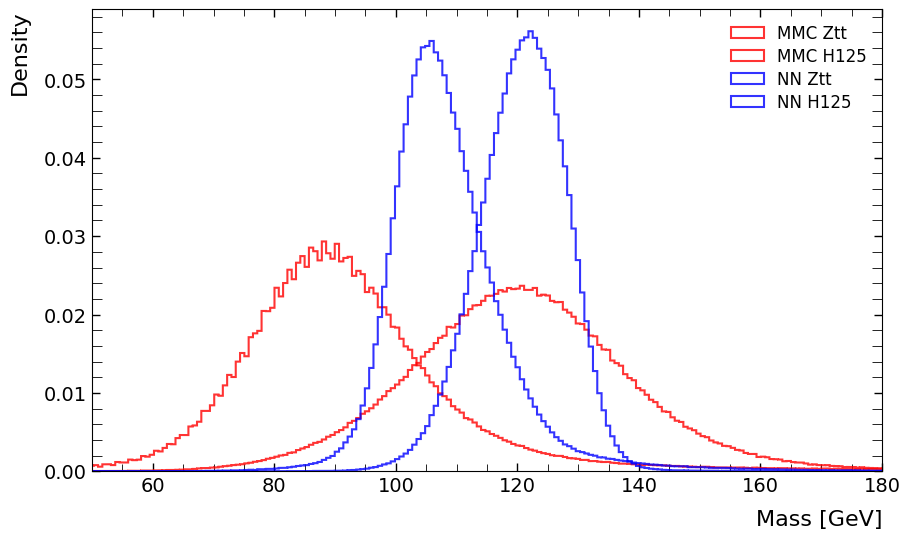

In [13]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# --- Helper Function for Analysis ---
def calculate_peak_fwhm(data, bins):
    """
    Calculates the peak and FWHM for a given distribution.

    Returns:
        peak_x (float): The x-value of the distribution's peak.
        fwhm (float): The Full Width at Half Maximum.
    """
    # 1. Calculate the histogram
    counts, bin_edges = np.histogram(data, bins=bins, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # 2. Find the peak
    max_height = np.max(counts)
    peak_x = bin_centers[np.argmax(counts)]

    # 3. Calculate FWHM
    half_max_height = max_height / 2.0
    # Find indices where the histogram is above half its maximum
    above_half_max_indices = np.where(counts > half_max_height)[0]

    if not len(above_half_max_indices):
        return peak_x, 0 # Cannot calculate FWHM if no points are above half max

    # The FWHM is the distance between the first and last points above the half-maximum
    fwhm = bin_centers[above_half_max_indices[-1]] - bin_centers[above_half_max_indices[0]]
    
    return peak_x, fwhm

# --- Assume your data is loaded ---
# y_mmc_Ztt, y_mmc_H125, y_pred_Ztt, y_pred_H125 = ...

# --- Your Existing Plotting Code ---
combined_data = np.concatenate([y_mmc_Ztt, y_mmc_H125, y_pred_Ztt, y_pred_H125])
optimal_bins = np.histogram_bin_edges(combined_data, bins="sqrt")

plt.figure(figsize=(10, 6))
plt.hist(y_mmc_Ztt, bins=optimal_bins, histtype='step', label='MMC Ztt', density=True, color='red', alpha=0.8, linewidth=1.5)
plt.hist(y_mmc_H125, bins=optimal_bins, histtype='step', label='MMC H125', density=True, color='red', alpha=0.8, linewidth=1.5)
plt.hist(y_pred_Ztt, bins=optimal_bins, histtype='step', label='NN Ztt', density=True, color='blue', alpha=0.8, linewidth=1.5)
plt.hist(y_pred_H125, bins=optimal_bins, histtype='step', label='NN H125', density=True, color='blue', alpha=0.8, linewidth=1.5)
plt.xlabel(r'Mass [GeV]', fontsize=16, horizontalalignment='right', x=1)
plt.ylabel(r'Density', fontsize=16, horizontalalignment='right', y=1)
plt.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6, width=1)
plt.xlim(50, 180)
plt.legend(fontsize=12)
plt.savefig("out_discussion/mmc_distribution_comparison.png", dpi=300)

# --- Analysis and Results ---
# 📊 Create a dictionary of your datasets for easy iteration
datasets = {
    "MMC Ztt": y_mmc_Ztt,
    "MMC H125": y_mmc_H125,
    "NN Ztt": y_pred_Ztt,
    "NN H125": y_pred_H125
}

print(f"{'Distribution':<15} | {'Peak (GeV)':<15} | {'FWHM (GeV)':<15}")
print("-" * 50)

for name, data in datasets.items():
    peak, fwhm = calculate_peak_fwhm(data, optimal_bins)
    print(f"{name:<15} | {peak:<15.2f} | {fwhm:<15.2f}")

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_widths

def analyze_distribution(data, bins):
    """
    Finds the primary peak and FWHM of a distribution using SciPy.

    Args:
        data (np.array): The input data array.
        bins (np.array): The histogram bin edges.

    Returns:
        A tuple containing (peak_position, fwhm) or (None, None) if no peak is found.
    """
    # 1. Calculate the histogram
    counts, bin_edges = np.histogram(data, bins=bins, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 2. Find all peaks in the histogram data
    # We set a minimum height to avoid noise being registered as peaks.
    peaks, properties = find_peaks(counts, height=np.max(counts)*0.1)

    if not peaks.any():
        return None, None # No peaks were found

    # 3. Identify the main peak (the one with the highest density)
    main_peak_index = peaks[np.argmax(properties['peak_heights'])]
    peak_position = bin_centers[main_peak_index]

    # 4. Calculate the FWHM for the main peak
    # We request the width at 50% of the peak's prominence (rel_height=0.5)
    widths, _, _, _ = peak_widths(counts, [main_peak_index], rel_height=0.5)
    
    # 5. Convert width from number of bins to the units of the x-axis (GeV)
    bin_width = bin_centers[1] - bin_centers[0]
    fwhm = widths[0] * bin_width

    return peak_position, fwhm

# --- Main Analysis ---
hist_bins = np.linspace(0.0, 180.0, 1001) # 1000 bins -> 1001 edges

# Analyze the H125 distribution
print("\n--- Predicted H125 Distribution ---")
peak_h125, fwhm_h125 = analyze_distribution(y_pred_H125, bins=hist_bins)
if peak_h125 is not None:
    print(f"Peak Position (Mode): {peak_h125:.3f}")
    print(f"STD: {np.std(y_pred_H125):.3f}")
else:
    print("Could not calculate FWHM for H125 distribution.")

# Analyze the Ztt distribution
print("\n--- Predicted Ztt Distribution ---")
peak_ztt, fwhm_ztt = analyze_distribution(y_pred_Ztt, bins=hist_bins)
if peak_ztt is not None:
    print(f"Peak Position (Mode): {peak_ztt:.3f}")
    print(f"STD: {np.std(y_pred_Ztt):.3f}")
else:
    print("Could not calculate FWHM for Ztt distribution.")

peak_mmc_h125, fwhm_mmc_h125 = analyze_distribution(y_mmc_H125, bins=hist_bins)
peak_mmc_ztt, fwhm_mmc_ztt = analyze_distribution(y_mmc_Ztt, bins=hist_bins)  

print("\n--- MMC H125 Distribution ---")
if peak_mmc_h125 is not None:
    print(f"Peak Position (Mode): {peak_mmc_h125:.3f}")
    print(f"STD: {np.std(y_mmc_H125):.3f}")
else:
    print("Could not calculate FWHM for MMC H125 distribution.")
print("\n--- MMC Ztt Distribution ---")

if peak_mmc_ztt is not None:
    print(f"Peak Position (Mode): {peak_mmc_ztt:.3f}")
    print(f"STD: {np.std(y_mmc_Ztt):.3f}")
else:
    print("Could not calculate FWHM for MMC Ztt distribution.")

peak_true_h125, fwhm_true_h125 = analyze_distribution(y_true_H125, bins = hist_bins)
peak_true_ztt, fwhm_true_ztt = analyze_distribution(y_true_Ztt, bins = hist_bins)

print("\n--- TRUE H125 Distribution ---")
if peak_true_h125 is not None:
    print(f"Peak Position (Mode): {peak_true_h125:.3f}")
    print(f"STD: {np.std(y_true_H125):.3f}")
else:
    print("Could not calculate FWHM for TRUE H125 distribution.")
print("\n--- TRUE Ztt Distribution ---")

if peak_true_ztt is not None:
    print(f"Peak Position (Mode): {peak_true_ztt:.3f}")
    print(f"STD: {np.std(y_true_Ztt):.3f}")
else:
    print("Could not calculate FWHM for MMC Ztt distribution.")


#calculate the mode and std of the reisdial distribution
residuals_NN = y_pred_H125 - y_true_H125
residual_mmc = y_mmc_H125 - y_true_H125

print("\n--- Residuals NN ---")
peak_NN, fwhm_NN = analyze_distribution(residuals_NN, bins=hist_bins)
if peak_NN is not None:
    print(f"Peak Position (Mode): {peak_NN:.3f}")
    print(f"STD: {np.std(residuals_NN):.3f}")
else:
    print("Could not calculate FWHM for residuals H125 distribution.")

print("\n--- Residuals MMC ---")
peak_residual_mmc, fwhm_residual_h125 = analyze_distribution(residual_mmc, bins=hist_bins)
if peak_residual_mmc is not None:
    print(f"Peak Position (Mode): {peak_residual_mmc:.3f}")
    print(f"STD: {np.std(residual_mmc):.3f}")
else:
    print("Could not calculate FWHM for residuals H125 distribution.")
# --- Your plotting code ---
#plt.figure(figsize=(10, 6))
# Note: Your labels were swapped in the original code, corrected here.
#plt.hist(y_pred_Ztt, bins=hist_bins, histtype='step', label=f'Predicted Ztt Mass Values', density=True)
#plt.hist(y_pred_H125, bins=hist_bins, histtype='step', label=f'Predicted H125 Mass Values', density=True)
#plt.xlabel("Output Mass [GeV]")
#plt.ylabel("Density")
#plt.xlim(50, 180)
#plt.title("Predicted Distribution on Validation Set")
#plt.legend()
#plt.grid(True)
#plt.savefig("predicted_vs_true_distribution.png", dpi=300)


--- Predicted H125 Distribution ---
Peak Position (Mode): 121.770
STD: 7.345

--- Predicted Ztt Distribution ---
Peak Position (Mode): 106.110
STD: 10.667

--- MMC H125 Distribution ---
Peak Position (Mode): 123.030
STD: 23.971

--- MMC Ztt Distribution ---
Peak Position (Mode): 90.090
STD: 35.208

--- TRUE H125 Distribution ---
Peak Position (Mode): 125.010
STD: 8.506

--- TRUE Ztt Distribution ---
Peak Position (Mode): 91.350
STD: 37.079

--- Residuals NN ---
Peak Position (Mode): 1.710
STD: 9.929

--- Residuals MMC ---
Peak Position (Mode): 2.070
STD: 23.457


findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not foun

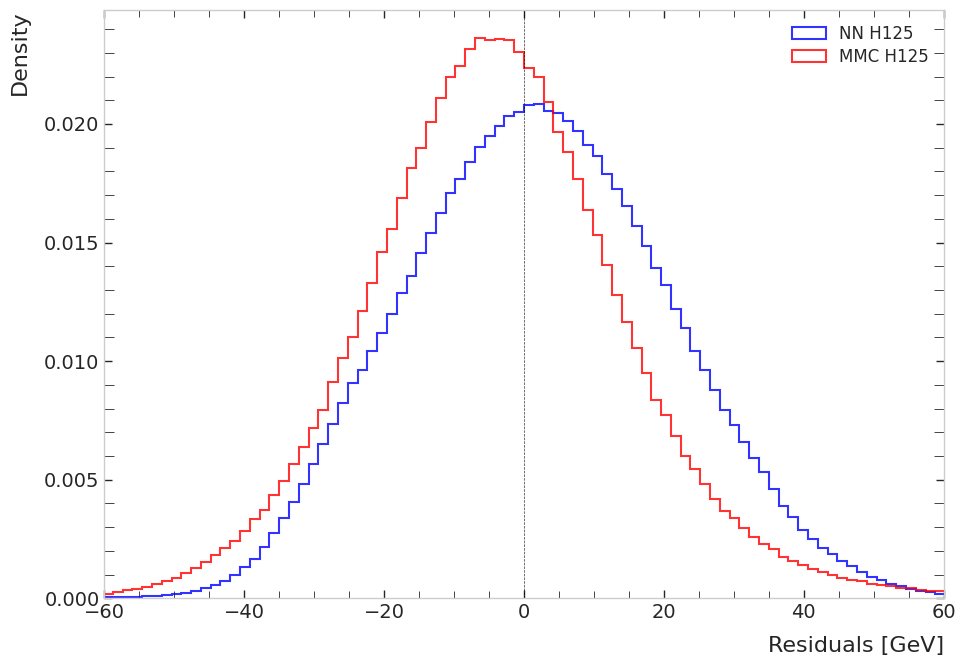

In [76]:
#plot residuals with respect to true mass 
plt.figure(figsize=(10, 7))
plt.hist(y_pred_H125 - y_true_H125, bins=100, range=(-70, 70), histtype='step',
         label='NN H125', density=True, color='blue', alpha=0.8, linewidth=1.5)

plt.hist(y_mmc_H125 - y_true_H125, bins=100, range=(-70, 70), histtype='step',
         label='MMC H125', density=True, color='red', alpha=0.8, linewidth=1.5)

plt.axvline(0, color='black', linestyle='--', linewidth=0.5, alpha = 0.8)
plt.xlabel(r'Residuals [GeV]', fontsize=16, horizontalalignment='right', x=1)
plt.ylabel(r'Density', fontsize=16, horizontalalignment='right', y=1)
plt.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6, width=1)
plt.legend(fontsize=12)
plt.xlim(-60, 60)
plt.grid(False)
plt.savefig('out/residuals_H125_MMC_NN.png', dpi=300)
plt.tight_layout()
plt.show()  

True mass bins: [ 20.  32.  44.  56.  68.  80.  92. 104. 116. 128. 140. 152. 164. 176.
 188. 200.]


findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not foun

average SEM NN: 0.9490206353882742
average SEM MMC: 1.73661796358213


findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not foun

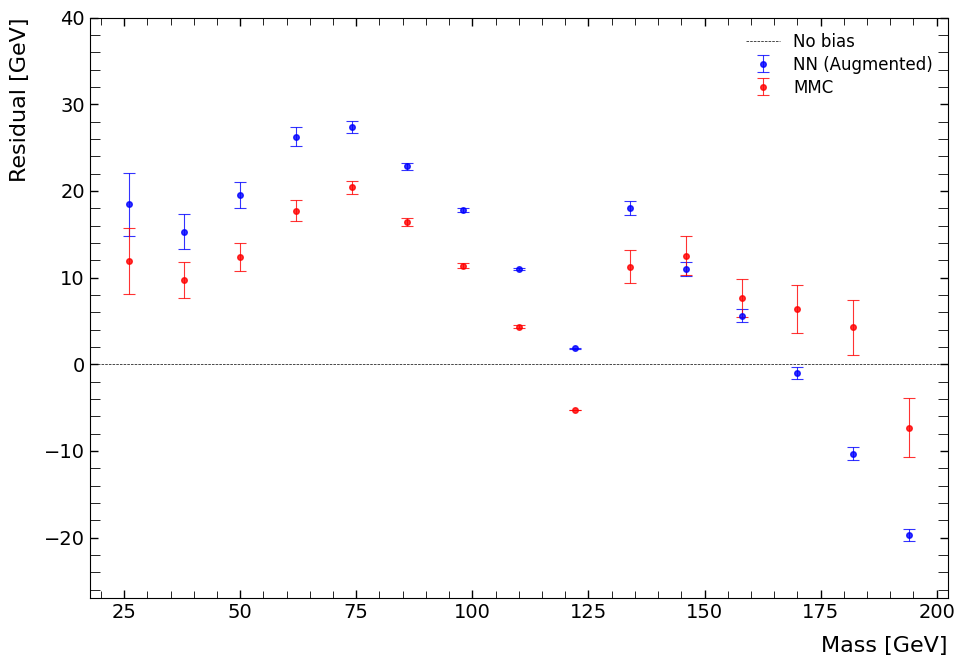

In [12]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt


# 1. Calculate residuals for both models
residuals_nn = y_pred_H125 - y_true_H125
residuals_mmc = y_mmc_H125 - y_true_H125

# 2. Define the bins based on the true mass
n_intervals = 15
true_mass_bins = np.linspace(20.0, 200.0, n_intervals + 1)
print(f"True mass bins: {true_mass_bins}")
# 3. Calculate binned statistics for the NN model
mean_residuals_nn, _, _ = stats.binned_statistic(
    y_true_H125, residuals_nn, statistic='mean', bins=true_mass_bins
)
std_residuals_nn, _, _ = stats.binned_statistic(
    y_true_H125, residuals_nn, statistic='std', bins=true_mass_bins
)

# 4. Calculate binned statistics for the MMC model
mean_residuals_mmc, _, _ = stats.binned_statistic(
    y_true_H125, residuals_mmc, statistic='mean', bins=true_mass_bins
)
std_residuals_mmc, _, _ = stats.binned_statistic(
    y_true_H125, residuals_mmc, statistic='std', bins=true_mass_bins
)

# 5. Count the number of samples per bin (same for both models)
count_per_bin, _, _ = stats.binned_statistic(
    y_true_H125, y_true_H125, statistic='count', bins=true_mass_bins
)

# 6. Calculate the Standard Error of the Mean (SEM) for both models
# Ensure we don't divide by zero for bins with no data
count_per_bin_float = count_per_bin.astype(float)
# Replace zero counts with NaN to avoid division errors and propagate NaN
count_per_bin_float[count_per_bin_float == 0] = np.nan

sem_nn = std_residuals_nn / np.sqrt(count_per_bin_float)
sem_mmc = std_residuals_mmc / np.sqrt(count_per_bin_float)
print(f"average SEM NN: {np.mean(sem_nn)}")
print(f"average SEM MMC: {np.mean(sem_mmc)}")
# 7. Prepare data for plotting
bin_centers = (true_mass_bins[:-1] + true_mass_bins[1:]) / 2


plt.figure(figsize=(10, 7))
plt.axhline(0, color='black', linestyle='--', linewidth=0.5, label='No bias')

plt.errorbar(
    bin_centers,
    mean_residuals_nn,
    yerr=sem_nn,
    fmt='o',  # Format: 'o' for circles
    capsize=4,
    markersize=4,
    color='blue',
    label='NN (Augmented)',
    alpha=0.8,
    capthick=0.8,
    elinewidth=0.8
)

plt.errorbar(
    bin_centers,
    mean_residuals_mmc,
    yerr=sem_mmc,
    fmt='o',  # Format: 'o' for circles
    capsize=4,
    markersize=4,
    color='red',
    label='MMC',
    alpha=0.8,
    capthick=0.8,
    elinewidth=0.8
)


plt.xlabel(r'Mass [GeV]', fontsize=16, horizontalalignment='right', x=1)
plt.ylabel(r'Residual [GeV]', fontsize=16, horizontalalignment='right', y=1)
plt.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6, width=1)
plt.legend(fontsize=12)
plt.ylim(-27, 40)
plt.tight_layout()
plt.grid(False)
plt.savefig('out/mean_residual_plot.png', dpi=300)
plt.show()  


findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not found because none of the following families were found: helvetica, Helvetica, Nimbus Sans L, Mukti Narrow, FreeSans
findfont: Generic family 'sans-serif' not foun

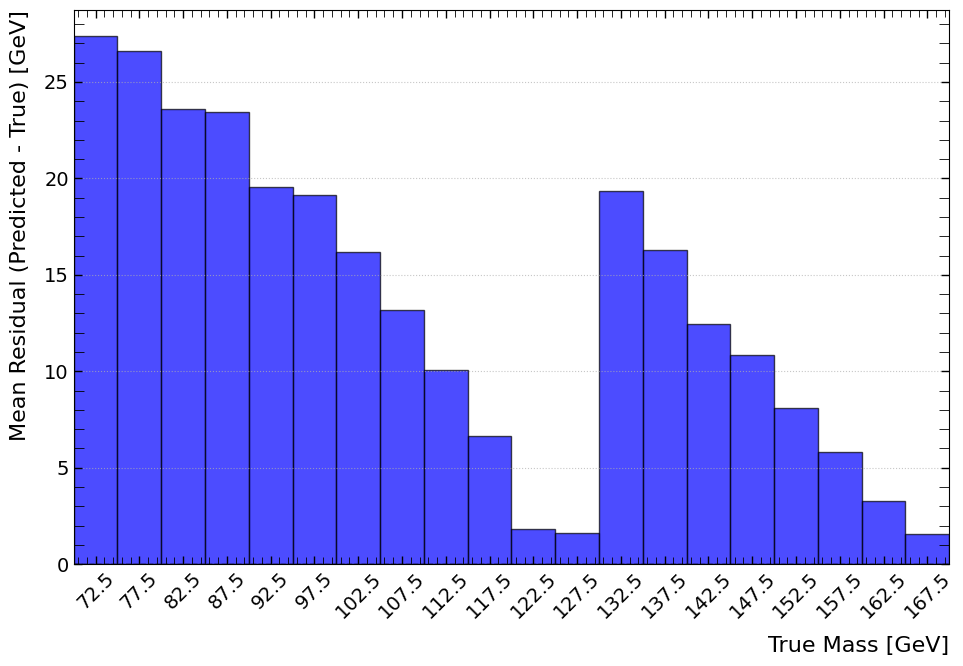

In [ ]:

from scipy.stats import binned_statistic

# --- Calculate residuals once ---
residuals_h125 = y_pred_H125 - y_true_H125

# --- Define bins ---
bins = np.linspace(70, 170, 21)  # 20 bins from 70 to 170 GeV

# --- Use binned_statistic to calculate the mean in each bin ---
# This single line replaces the entire for-loop.
# It bins 'y_true_H125' and computes the mean of the corresponding 'residuals_h125' for each bin.
mean_residuals, _, _ = binned_statistic(y_true_H125, residuals_h125, statistic='mean', bins=bins)

# binned_statistic returns NaN for empty bins, so we replace them with 0 to match your original logic.
np.nan_to_num(mean_residuals, copy=False)

# --- Plotting (remains mostly the same) ---
plt.figure(figsize=(10, 7))
bin_centers = (bins[:-1] + bins[1:]) / 2

plt.bar(bin_centers, mean_residuals, width=np.diff(bins), align='center', alpha=0.7, color='blue', edgecolor='black')
plt.axhline(0, color='black', linestyle='--', linewidth=1) # Add a zero line for reference
plt.xlabel(r'True Mass [GeV]', fontsize=16, horizontalalignment='right', x=1)
plt.ylabel(r'Mean Residual (Predicted - True) [GeV]', fontsize=16, horizontalalignment='right', y=1)
plt.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6, width=1)
plt.xlim(70, 170)
plt.xticks(bin_centers, rotation=45)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('mean_residuals_H125_binned_statistic.png', dpi=300)
plt.show()